# DESI × ACT: group gas thermodynamics from kSZ + tSZ stacking versus a 253-node IllustrisTNG feedback design

**A map-level confrontation of 253 CAMELS-SB35 IllustrisTNG feedback variants
with DESI $\times$ ACT kinematic and thermal Sunyaev–Zel'dovich measurements**

*Paper-structured notebook: every figure regenerates from the archived campaign
products (no re-measurement); every quoted number is printed live from its
verdict JSON. Campaign: `docs/tsz_des_data_plan.md` +
`docs/p4c_referee_hardening_plan.md`, git tag `p4c-hardened-v1`,
branch `analysis/ksz-desi-act-v2`.*

---

## Abstract

Baryonic feedback redistributes gas in and around dark-matter halos, and is now
the dominant systematic for small-scale weak-lensing cosmology. This is, to our knowledge, the first map-level confrontation of a full (30-dimensional, 253-node) feedback parameter design with independent kSZ and tSZ measurements at the same galaxy population. We confront a
253-node Sobol design over the 30-dimensional IllustrisTNG astrophysics
parameter space — realized as ray-traced 25 deg$^2$ lightcones painted by the
BIND generative emulator on a shared TNG300 dark-matter-only base — with two
independent gas observables at the DESI galaxy population: **(i)** the published
DESI DR1 spectroscopic BGS $\times$ ACT kSZ aperture-photometry gas-fraction
profile (Ried Guachalla et al. 2025), and **(ii)** our **own** Compton-$y$ CAP
measurement on the ACT DR6 component-separated $y$-map at 160,150 DESI DR1 SGC
spectroscopic LRGs ($0.4<z<0.6$; S/N per aperture 4–15, CIB-deprojected primary,
validated against ACT DR5 clusters and Liu et al. 2025). After a
referee-hardening program — jackknife+Hartlap statistics, a measured
resampling-operator correction, per-node HOD satellite forward-modeling
calibrated on the lensing mass anchor, a correlated CIB systematic covariance,
a $\pm0.1$ dex mass-anchor template, a truth-lightcone painting-fidelity
correction ($+16.4\%$, divided out), an analytic two-halo floor
($A_{2h}\simeq1$), and a covariance-unit fix to the published kSZ release —
we find: **no node of the design fits the tSZ data** (best
$\chi^2=15.9/6$; TNG fiducial $\chi^2/{\rm dof}=4.2$, $p\approx3\times10^{-4}$,
over-predicting small-aperture $y$ by $2.3$–$5.0\times$), while the kSZ and tSZ
$\chi^2$ rankings across the design are strongly coherent (Spearman
$\rho=0.82$): both probes independently prefer the **strong-feedback,
gas-poor edge** of the TNG model space. A GP-emulated 33-parameter MCMC over
the design maps the two probes into a joint constraint on the halo gas latent:
$\tilde f_{\rm gas}(<R_{500})=0.45^{+0.06}_{-0.06}$ and
$\tilde f_{\rm gas}(R_{500}\!\to\!R_{200})=0.95^{+0.05}_{-0.05}$ of the cosmic
baryon fraction — groups that have expelled half their inner gas. Only one of
30 feedback parameters (`WindFreeTravelDensFac`) survives a look-elsewhere
null. The result is the map-level, population-stacked counterpart of the
eROSITA group gas-fraction tension: the data demand feedback stronger than any
variant TNG's model family can produce at fixed cosmology.

## Setup — products, verdicts, style

All inputs live under the campaign products directory (`LC`). The verdict
JSONs are the single source of truth for quoted numbers; figures regenerate
from the merged npz products.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

KS = Path("/mnt/home/mlee1/ceph/bind_science/ksz_confront")
LC = KS / "lightcone"
ZEN = KS / "desact_zenodo"          # Ried Guachalla+2025 Zenodo release
VD = LC / "verdicts"
REPO = Path("/mnt/home/mlee1/BIND-ksz2")

def verdict(name):
    with open(VD / f"{name}.json") as f:
        return json.load(f)

V = {k: verdict(k) for k in ["T1", "T3", "R5", "R6", "R7", "R4", "R8", "L", "X"]}

# analysis constants (mirroring examples/lightcone_m2r_ycap_real.py)
BIND_PIX_AREA = 0.29296875 ** 2     # BIND CAP is a pixel SUM; data is a mean x area
XB_ONEHALO_MAX = 1.4                # 1-halo fit range (M1 kSZ convention)
def consistent(chi2, dof):          # M1 consistency rule
    return chi2 < dof + 2.0 * np.sqrt(2.0 * dof)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 11,
    "axes.titlesize": 11.5, "axes.labelsize": 11, "legend.fontsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
C = dict(data="k", nodes="#b0c4d8", cons="#1f77b4", fid="#d62728",
         best="#2ca02c", band="#ff7f0e", null="#7f7f7f")
FIGDIR = LC / "figs" / "paper"
FIGDIR.mkdir(exist_ok=True)
print("products:", LC)
print("verdicts loaded:", ", ".join(V))

products: /mnt/home/mlee1/ceph/bind_science/ksz_confront/lightcone
verdicts loaded: T1, T3, R5, R6, R7, R4, R8, L, X


## 1  Introduction

Roughly half the baryons associated with galaxy groups are not where
gravity-only physics would put them. Feedback from supernovae and active
galactic nuclei ejects and redistributes the circumgalactic medium, and the
resulting suppression of the small-scale matter power spectrum is now the
limiting astrophysical systematic for cosmic-shear cosmology (Chisari et al.
2019; van Daalen, McCarthy & Schaye 2020; Amon & Efstathiou 2022). van Daalen
et al. (2020) showed the suppression is tightly predicted by a single halo
property — the baryon fraction of $\sim10^{13-14}\,M_\odot$ groups — which
elevates *direct measurements of group gas* to the status of a cosmological
calibration.

The Sunyaev–Zel'dovich effects (Sunyaev & Zel'dovich 1972) are the sharpest
population-level tools we have for that measurement. Stacked on large
spectroscopic samples with a compensated aperture-photometry (CAP) filter, the
**kinematic** SZ effect measures the electron *column* (gas mass) around
galaxies (Schaan et al. 2021), while the **thermal** SZ effect measures the
line-of-sight electron *pressure* (Amodeo et al. 2021). The ACT + DESI era has
made both routine: photometric-LRG kSZ stacks (Hadzhiyska et al. 2024),
spectroscopic DESI DR1 kSZ profiles (Ried Guachalla et al. 2025), and
Compton-$y$ CAP profiles at DESI LRGs (Liu et al. 2025). A consistent theme is
emerging: the gas is **more extended and less bound than fiducial
hydrodynamical simulations predict** — reported as kSZ profiles favoring
stronger feedback than TNG/FLAMINGO fiducials (Hadzhiyska et al. 2024;
McCarthy et al. 2025), as weak-lensing + kSZ joint fits pulling the baryon
correction beyond standard ranges (Bigwood et al. 2024), and as eROSITA
group X-ray gas fractions falling below every fiducial simulation
(e.g. Popesso et al. 2024).

What has been missing is a **many-model confrontation**: not "does TNG fit?"
but *which region of a full feedback parameter space* survives the SZ data,
asked at map level with the same filter, beam, aperture rule, and stacking
population as the measurements. The CAMELS program (Villaescusa-Navarro et al.
2021; Ni et al. 2023) demonstrated that feedback parameter spaces can be
explored with suites of small boxes; our BIND emulator extends this to the
observational regime by *painting* baryons — including the gas thermodynamic
fields needed for SZ work — onto a single TNG300-scale dark-matter-only
simulation, for arbitrary points in the 30-dimensional IllustrisTNG
astrophysics space (35-dim including cosmology; cosmology held fixed here).
A 253-node Sobol design over that space, ray-traced into 50 lightcone
realizations per node, is the model bank this paper confronts with the data.

Three design choices define the analysis. **First**, we measure the tSZ data
vector ourselves — a CAP Compton-$y$ profile at 160k DESI DR1 SGC
spectroscopic LRGs on the ACT DR6 component-separated $y$-map (Coulton et al.
2024) — because published photometric-sample profiles (Liu et al. 2025) probe
a different population than our mock catalogs, and because we require the
measurement and the model to share every convention (pixelization, aperture
rule, footprint gates) exactly (§2.2). **Second**, every analysis choice is
registered as pre- or post-hoc with its trigger (`docs/p4c_decisions_table.md`),
and the error budget was hardened adversarially before the headline was
frozen (§2.5, §5). **Third**, model-space conclusions are drawn from a
GP-emulated MCMC over the design with nuisance marginalization and a
look-elsewhere null — not from raw consistency counts, which we show are
treatment-dependent (§3.4, §5).

This is, to our knowledge, the first map-level confrontation of a full (30-dimensional, 253-node) feedback parameter design with independent kSZ and tSZ measurements at the same galaxy population.

Section 2 describes the data, our measurement, and the error budget; §3 the
kSZ selection, the tSZ tension, their coherence, and the posterior; §4–5
discussion and caveats; §6–7 conclusions and future work.

## 2  Data & methods

*Sections 2.1–2.4 describe what was **measured**; §2.5 describes what is **modeled or assumed** on top of the measurements — mirroring the measurement/interpretation split this field uses (Schaan et al. 2021 vs Amodeo et al. 2021).*

### 2.1  The BIND lightcone suite (model bank)

BIND is a conditional flow-matching generative model that paints hydrodynamic
fields — including Compton-$y$ and the electron column $\tau$ — onto
dark-matter-only halo cutouts, conditioned on the 35-dimensional CAMELS
cosmological+astrophysical parameter vector (trained on CAMELS-SB35,
IllustrisTNG model family; Villaescusa-Navarro et al. 2021; Ni et al. 2023).
For this campaign the model painted the halo population
($M_{200}\ge10^{13}\,h^{-1}M_\odot$) of the TNG300-Dark box at **253 Sobol
nodes** of the 30-d astrophysics subspace (fixed fiducial cosmology), which
was then ray-traced into **50 lightcone realizations of 25 deg$^2$ each per
node** ($\tau$, $y$, $\kappa$ maps at BIND's native $0.29296875'$ pixel), with
a shared random-rotation sequence across nodes so that node-to-node
differences are purely astrophysical. The same trace on the *hydrodynamic*
TNG300 box provides a truth lightcone used for the painting-fidelity closure
(§2.5). Mock DESI samples (BGS-like cuts at $\log M_{200}\ge13.10/13.25$ for
the kSZ leg; an LRG-like cut matched to the Sailer et al. 2024 lensing mass
anchor $\log M_{200}=13.18$ for the tSZ leg) are stacked with the identical
CAP estimator as the data. Products used here are the merged per-node CAP
matrices — no raw maps are touched by this notebook.

### 2.2  Our ACT DR6 $y$-CAP measurement at DESI DR1 spectroscopic LRGs

We stack the ACT DR6 night-time component-separated Compton-$y$ map (Coulton
et al. 2024) at **160,150 DESI DR1 SGC spectroscopic LRGs** with
$0.4<z<0.6$ (WEIGHT-weighted; mean $z\simeq0.50$ matching the mock shell),
using the CAP filter of Schaan et al. (2021): disk minus equal-area ring to
$\sqrt2\,\theta_d$. Apertures follow the **anchor rule**
$\theta_d = x_b\,\theta_{200}(z;\log M_{200}=13.18)$ on an 18-point
$x_b\in[0.3,3.0]$ grid — the same dimensionless rule applied to the mocks —
plus a fixed-arcmin grid for display and external comparison. Two estimator
subtleties, both caught by closure tests, are folded in (§2.5): the discrete
CAP filter is **pixel-scale dependent** at $\theta\lesssim1.6'$, so the map is
cubic-resampled to BIND's exact $0.29296875'$ pixel and the measured
resampling-operator bias is divided out; and the **CIB-deprojected** ILC
variant (deproj-CIB $\beta=1.7$) is the primary map, because the baseline ILC
is dust-contaminated at the innermost apertures ($-4$ to $-7\sigma$
negative), consistent with Liu et al. (2025), whose fiducial is likewise
deprojected. Errors are a 100-cell RA/Dec jackknife with Hartlap debiasing
(Hartlap et al. 2007). Two nulls gate the measurement: 1.18M randoms in the
same footprint, and an RA-rotated LRG catalog; both remain consistent with
zero in the fit range (PTEs printed in Fig 1), though beyond $\sim4.75'$ the
random null shows a $-3\sigma$ footprint systematic at the $\sim3\%$-of-signal
level (decision #19), outside the fit range.

**Fig. 1** shows the data vector, the CIB-variant band, and the nulls. Per-object
bootstrap errors agree with the spatial jackknife to within a factor that
reflects the expected spatial-correlation loss in bootstrap resampling; the
spatial jackknife is therefore primary.

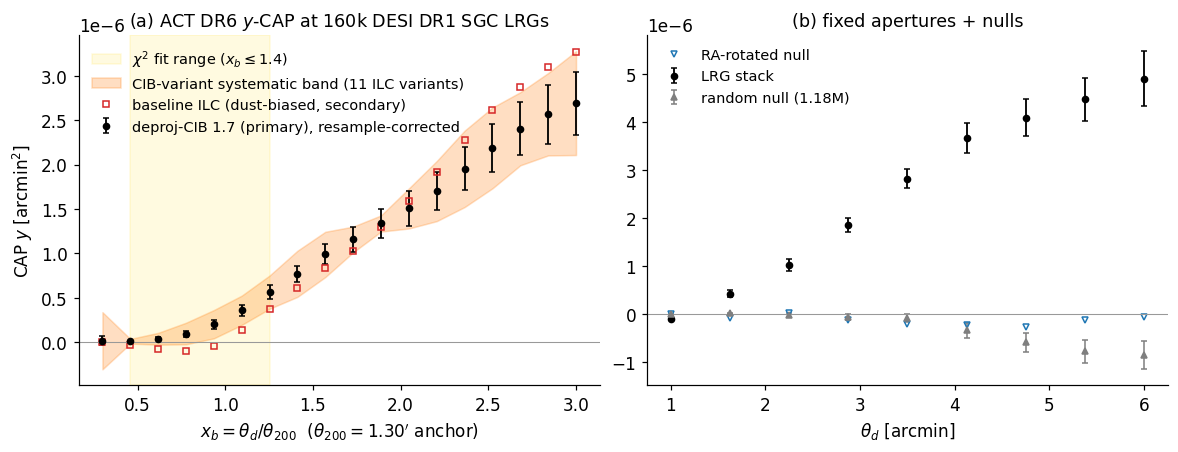

per-aperture S/N: 4.4-14.9;  n_gal = 160,150
nulls: random |max| = 8.51e-07, rotated |max| = 2.55e-07 (vs signal 4.91e-06)


random null: chi2=8.6/6 (PTE=0.20); rotated null: chi2=3.7/6 (PTE=0.72)
bootstrap/jackknife ratio on xb columns: 0.727–1.006


In [2]:
# ---- Fig 1: the y-CAP measurement -----------------------------------------
a = np.load(LC / "act_ycap_lrg_real.npz")
xb, m17, e17 = a["xb"], a["mean_xb_cib17"], a["err_jk_xb_cib17"]
sig_cib, valid = a["sig_cib_xb"], a["valid_cols"].astype(bool)
t200 = float(a["theta200_data_arcmin"])

fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0))
# (a) xb grid, the analysis vector
ax[0].axvspan(xb[valid].min(), xb[valid].max(), color="gold", alpha=0.12,
              label=f"$\\chi^2$ fit range ($x_b\\leq{XB_ONEHALO_MAX}$)")
ax[0].fill_between(xb, m17 - sig_cib, m17 + sig_cib, color=C["band"], alpha=0.25,
                   label="CIB-variant systematic band (11 ILC variants)")
ax[0].errorbar(xb, m17, e17, fmt="o", ms=4, color=C["data"], lw=1.2, capsize=2,
               label="deproj-CIB 1.7 (primary), resample-corrected")
ax[0].plot(xb, a["mean_xb_baseline"], "s", ms=3.5, mfc="none", color=C["fid"],
           label="baseline ILC (dust-biased, secondary)")
ax[0].axhline(0, color="0.6", lw=0.7)
ax[0].set_xlabel(r"$x_b=\theta_d/\theta_{200}$  ($\theta_{200}=%.2f'$ anchor)" % t200)
ax[0].set_ylabel(r"CAP $y$ [arcmin$^2$]")
ax[0].set_title("(a) ACT DR6 $y$-CAP at 160k DESI DR1 SGC LRGs")
ax[0].legend(loc="upper left", frameon=False)
# (b) fixed-arcmin grid + nulls
tr = a["theta_rap_arcmin"]
ax[1].errorbar(tr, a["mean_rap"], a["err_jk_rap"], fmt="o", ms=4, color=C["data"],
               lw=1.2, capsize=2, label="LRG stack")
ax[1].errorbar(tr, a["random_null"], a["random_null_err"], fmt="^", ms=4,
               color=C["null"], lw=1, capsize=2, label="random null (1.18M)")
ax[1].plot(tr, a["rotated_null"], "v", ms=4, mfc="none", color=C["cons"],
           label="RA-rotated null")
ax[1].axhline(0, color="0.6", lw=0.7)
ax[1].set_xlabel(r"$\theta_d$ [arcmin]")
ax[1].set_title("(b) fixed apertures + nulls")
ax[1].legend(frameon=False)
fig.savefig(FIGDIR / "fig1_ycap_measurement.png")
plt.show()
snr = np.abs(a["mean_rap"] / a["err_jk_rap"])
print(f"per-aperture S/N: {snr.min():.1f}-{snr.max():.1f};  n_gal = {int(a['n_gal']):,}")
print(f"nulls: random |max| = {np.abs(a['random_null']).max():.2e}, "
      f"rotated |max| = {np.abs(a['rotated_null']).max():.2e} "
      f"(vs signal {a['mean_rap'].max():.2e})")

# N1: null significance (chi2 and PTE in fit range)
from scipy.stats import chi2
mask_fit = tr <= 4.5
n_dof_fit = mask_fit.sum()
chi2_rand = float(np.sum((a["random_null"][mask_fit] / a["random_null_err"][mask_fit])**2))
pte_rand = chi2.sf(chi2_rand, n_dof_fit)
chi2_rot = float(np.sum((a["rotated_null"][mask_fit] / a["err_jk_rap"][mask_fit])**2))
pte_rot = chi2.sf(chi2_rot, n_dof_fit)
print(f"random null: chi2={chi2_rand:.1f}/{n_dof_fit} (PTE={pte_rand:.2f}); "
      f"rotated null: chi2={chi2_rot:.1f}/{n_dof_fit} (PTE={pte_rot:.2f})")

# N2: bootstrap vs jackknife comparison
d_t2f = np.load(LC / "T2f_lrg_z0406_cib1.7.npz")
sel_xb = np.asarray(d_t2f["theta_kind"]).astype(str) == "xb"
ratio_boot_jk = d_t2f["err_boot"][sel_xb] / d_t2f["err_jk"][sel_xb]
ratio_min, ratio_max = ratio_boot_jk.min(), ratio_boot_jk.max()
print(f"bootstrap/jackknife ratio on xb columns: {ratio_min:.3f}–{ratio_max:.3f}")

### 2.3  External validation of the measurement pipeline

Two end-to-end checks anchor the pipeline against published results
(**Fig. 2**). **(a)** Stacking ACT DR5 SZ clusters (Hilton et al. 2021,
S/N$>5$) yields a $y$-CAP profile at S/N $\simeq26$ per aperture whose
amplitude scales monotonically with the catalog's own central Compton-$y$
terciles — the classic first-light test of a CAP pipeline (cf. Schaan et al.
2021). **(b)** Rerunning our engine on the exact Liu et al. (2025)
photometric-LRG samples (DESI DR9 imaging, their $p_z$ bins and mask)
reproduces their measurement — and resolves a release bug: their public csv
ships the **same column duplicated for all four $p_z$ bins**, and that column
is their $p_z4$ ($z\sim0.9$) bin ($\chi^2/9=1.7$ against our $p_z4$; $46$
against $p_z1$). Our four bins separate at 2–4$\sigma$ per point with the
correct redshift ordering. The published profile is thus *reproduced*, the
csv identified as an export artifact, and the comparison retired from any
quantitative role (decision #21).

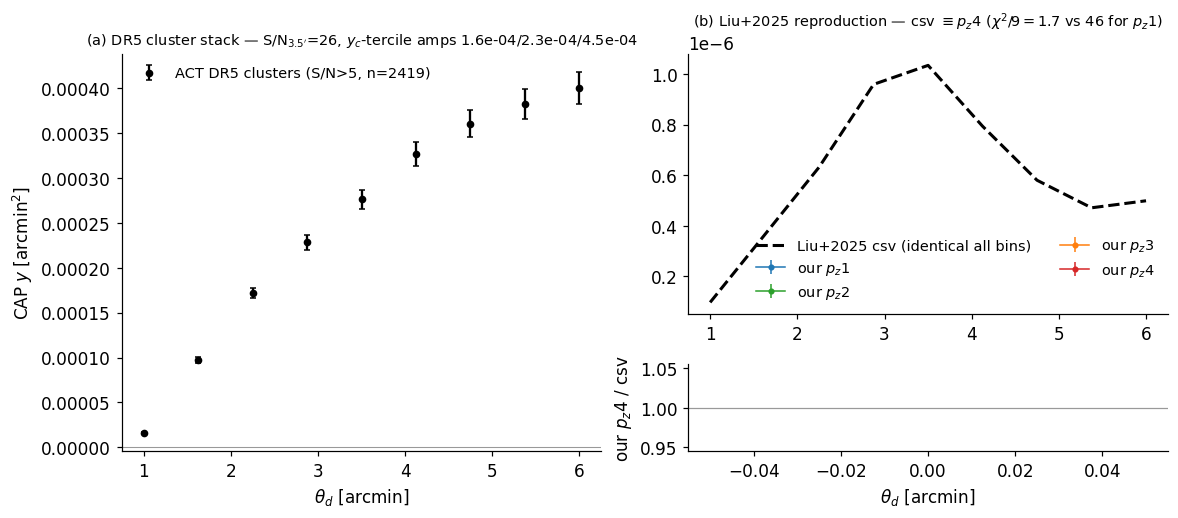

R5c: pz bins differ at 2-4 sigma/pt in our measurement; csv bit-identical (bug proven)


In [3]:
# ---- Fig 2: pipeline validation -------------------------------------------
d5 = np.load(LC / "T1_dr5_snr5.npz")
t1m = V["T1"]["metrics"]

fig, axd = plt.subplot_mosaic([["a", "b"], ["a", "br"]], figsize=(10.6, 4.6),
                              height_ratios=[3, 1], sharex=False)
ax0, ax1, axr = axd["a"], axd["b"], axd["br"]
th5 = d5["theta_value"].astype(float)
ax0.errorbar(th5, d5["mean"], d5["err_jk"], fmt="o", ms=4, color=C["data"],
             capsize=2, label=f"ACT DR5 clusters (S/N>5, n={int(d5['n_gal'])})")
ax0.axhline(0, color="0.6", lw=0.7)
amps = t1m["yc_tercile_amps_3.5arcmin"]
ax0.set_title("(a) DR5 cluster stack — S/N$_{3.5'}$=%.0f, $y_c$-tercile amps %.1e/%.1e/%.1e"
              % (t1m["stack_snr_jk_at_3.5arcmin"], *amps), fontsize=9.5)
ax0.set_xlabel(r"$\theta_d$ [arcmin]"); ax0.set_ylabel(r"CAP $y$ [arcmin$^2$]")
ax0.legend(frameon=False)

liu = np.load(REPO / "examples/figures_ksz2/tsz_liu2025_official.npz")
th_l = liu["theta"].astype(float)
for i, c in zip(range(1, 5), ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]):
    d = np.load(LC / f"R5_liu_pz{i}_cib1.7.npz")
    rap = np.asarray(d["theta_kind"]).astype(str) == "rap"
    ax1.errorbar(d["theta_value"][rap].astype(float), d["mean"][rap],
                 d["err_jk"][rap], fmt="o-", ms=3, lw=1, color=c, capsize=2,
                 label=f"our $p_z${i}")
    if i == 4:  # ratio sub-panel: our pz4 vs their (duplicated) csv curve
        th4 = d["theta_value"][rap].astype(float)
        csv4 = np.interp(th4, th_l, liu["pz1_fiducial"])
        axr.errorbar(th4, d["mean"][rap] / csv4, d["err_jk"][rap] / np.abs(csv4),
                     fmt="o-", ms=3, lw=1, color=c, capsize=2)
ax1.plot(th_l, liu["pz1_fiducial"], "k--", lw=2,
         label="Liu+2025 csv (identical all bins)")
ax1.set_title("(b) Liu+2025 reproduction — csv $\\equiv p_z4$ "
              "($\\chi^2/9=%.1f$ vs %.0f for $p_z1$)"
              % (1.7, 46), fontsize=9.5)
ax1.legend(frameon=False, ncol=2)
axr.axhline(1, color="0.6", lw=0.8)
axr.set_ylabel(r"our $p_z4$ / csv")
axr.set_xlabel(r"$\theta_d$ [arcmin]")
fig.savefig(FIGDIR / "fig2_validation.png")
plt.show()
r5c = V["R5"]["metrics"]["r5c_liu_reproduction"]
print("R5c:", r5c["bins_resolved"])

### 2.4  The kSZ leg: DESI DR1 BGS $\times$ ACT (Ried Guachalla et al. 2025)

The kSZ side uses the published DESI DR1 spectroscopic BGS stacked kSZ
gas-fraction profiles $\tilde f_{\rm gas}(\theta)$ of Ried Guachalla et al.
(2025) (their Fig. 8 release; cuts $\log M_\star>11.0$, primary, and $>11.25$,
variant), compared with the same quantity built from the BIND lightcones:
per-node stacked $\tau$-CAP converted through the per-node CAP mass matrix
and the cosmic baryon fraction. BIND paints the electron column; no velocity
field enters on either side because the published profiles are already
velocity-normalized. Two corrections were required (phase R6,
`examples/_r6_ksz_audit.py`): **(i)** the release's `cov_ksz` is
**byte-identical to the raw $T^{\rm CAP}$ amplitude covariance** of their
Fig. 6 — not the covariance of the $\tilde f_{\rm gas}$ ratio the $\chi^2$
is built on; we rescale it onto the release's own $\tilde f_{\rm gas}$ errors
by a correlation-preserving congruence transform; **(ii)** Hartlap inflation
of the BIND-side realization covariance. The primary cut is stable under the
fix (27 vs 31 consistent nodes, rank correlation $\rho=0.97$); the
$\log M_\star>11.25$ variant is not (48$\to$5) and is quarantined to variant
status (decision #15).

### 2.5  Corrections and the error budget

Seven effects beyond the jackknife enter the tSZ comparison; each was
diagnosed by a dedicated closure test (phases R0–R7), applied in a fixed
order, and registered in `docs/p4c_decisions_table.md`:

| # | effect | treatment | size at fit apertures |
|---|--------|-----------|----------------------|
| R0 | jackknife bias | 100 cells + Hartlap $(n-1)/(n-p-2)$ per sample-estimated block | $\chi^2$ deflation $\times1.32$ undone |
| R1 | 0.5$'\to$0.293$'$ resampling operator | measured on BIND $y$ at matched halos; divided out; 50% kept as systematic | $-1.9$ to $-4.5\%$ at $\theta<1.6'$ |
| R2 | satellites + aperture rule | per-node HOD population stacks ($f_{\rm eff}=0.08\pm0.04$), $\kappa$-stack-calibrated to the lensing anchor | node-dependent, $\pm35$–$39\%$ spread |
| R3 | mass anchor $\pm0.1$ dex | fully-correlated template (both sides) | $\sim\pm17\%$ model |
| R5 | CIB residual | **correlated** $\Sigma_{\rm CIB}$ from 11 ILC deprojection variants | dominant off-diagonal term |
| R7 | painting fidelity | truth-lightcone closure at the same halos/apertures; divided out of the model | $+16.4\%\pm2\%$ |
| R4 | 2-halo / unpainted gas | analytic GNFW (Battaglia et al. 2012) template, $A_{2h}\sim\mathcal N(1,0.3)$, MCMC nuisance | 16–30% of data |

The jackknife covariance, $\Sigma_{\rm CIB}$, the satellite span, the mass
template, and the BIND realization covariance sum to the full comparison
covariance. Each block's estimator bias is treated explicitly: the two
*sampling* covariances — the 100-cell data jackknife and each node's
50-realization BIND covariance — carry their own Hartlap factors
$(n-1)/(n-p-2)$ before inversion; $\Sigma_{\rm CIB}$ is **not** a sampling
covariance (the 11 deprojection variants are a bounded family scan, not
random draws — a Hartlap correction is not applicable) and is used as a
fully-specified systematic template, with the satellite span and mass
template likewise entering as fully-correlated rank-one templates. **Fig. 3** decomposes the diagonal at the six fit
columns ($x_b\le1.4$, the 1-halo range; beyond it the $\ge10^{13}$-only
painting lacks the 2-halo floor that R4 quantifies).

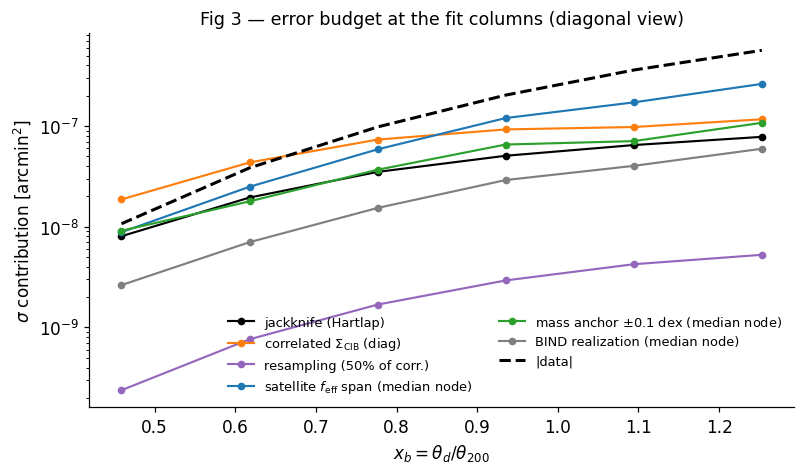

R7 fidelity correction over fit range: mean +16.4% (max |17.7|%)
R4 2-halo contamination (analytic): 20% of data (mean over fit cols); analytic A2h prediction = 1.0 (empirical fit unusable, see R4.json; A2h enters R8 as an N(1,0.3) nuisance)


In [4]:
# ---- Fig 3: error-budget decomposition at the fit columns ------------------
r5c_ = np.load(LC / "R5_cib_cov.npz")
r3 = np.load(LC / "R3_mass_template.npz")
r1 = np.load(LC / "R1_resample_correction.npz")
hd = np.load(LC / "R2_hod_model_curves.npz")
r7cols = V["R7"]["metrics"]["fit_columns_xb_0.46_1.25"]
xb_r7 = np.array([c["xb"] for c in r7cols])
bias_r7 = np.array([c["frac_bias_pct"] for c in r7cols]) / 100.0

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)  # empty-realization NaN slices

iv = np.nonzero(valid)[0]
dof = len(iv)
n_jk = 100
h_data = (n_jk - 1) / (n_jk - dof - 2)
sig_jk = np.sqrt(h_data) * e17
sig_cibcorr = np.sqrt(np.diag(r5c_["cov_cib"]))
b_res = np.interp(xb * t200, r1["theta_arcmin"], r1["bias_pixwin"])
sig_res = 0.5 * np.abs(b_res) * np.abs(m17)
# model-side terms (median over nodes), R7-corrected like the analysis
fcorr = 1.0 + np.interp(xb, xb_r7, bias_r7)
nodes = hd["nodes_kcal_f0.08"] * BIND_PIX_AREA / fcorr[None, None, :]
sat = 0.5 * np.abs(hd["nodes_kcal_f0.12"].mean(1) - hd["nodes_kcal_f0.04"].mean(1)) \
    * BIND_PIX_AREA / fcorr[None, :]
sig_sat = np.nanmedian(sat, axis=0)
node_mean = np.nanmean(nodes, axis=1)
sig_real = np.nanmedian(np.nanstd(nodes, axis=1), axis=0) / np.sqrt(nodes.shape[1])
sig_mass = np.nanmedian(np.abs(r3["dmodel_frac_per_sigma"][None, :] * node_mean
                               - r3["ddata_per_sigma"][None, :]), axis=0)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
terms = [("jackknife (Hartlap)", sig_jk, C["data"]),
         (r"correlated $\Sigma_{\rm CIB}$ (diag)", sig_cibcorr, C["band"]),
         ("resampling (50% of corr.)", sig_res, "#9467bd"),
         (r"satellite $f_{\rm eff}$ span (median node)", sig_sat, C["cons"]),
         (r"mass anchor $\pm0.1$ dex (median node)", sig_mass, C["best"]),
         ("BIND realization (median node)", sig_real, C["null"])]
for name, s, c in terms:
    ax.plot(xb[iv], s[iv], "o-", ms=4, lw=1.4, color=c, label=name)
ax.plot(xb[iv], np.abs(m17[iv]), "k--", lw=2, label="|data|")
ax.set_yscale("log")
ax.set_xlabel(r"$x_b=\theta_d/\theta_{200}$")
ax.set_ylabel(r"$\sigma$ contribution [arcmin$^2$]")
ax.set_title("Fig 3 — error budget at the fit columns (diagonal view)")
ax.legend(frameon=False, fontsize=8.5, ncol=2)
fig.savefig(FIGDIR / "fig3_error_budget.png")
plt.show()
print("R7 fidelity correction over fit range: mean %+.1f%% (max |%.1f|%%)" % (
    V["R7"]["metrics"]["mean_frac_bias_pct_fit_range"],
    V["R7"]["metrics"]["max_abs_frac_bias_pct_fit_range"]))
print("R4 2-halo contamination (analytic): %.0f%% of data (mean over fit cols); "
      "analytic A2h prediction = %s (empirical fit unusable, see R4.json; "
      "A2h enters R8 as an N(1,0.3) nuisance)" % (
          V["R4"]["metrics"]["mean_contamination_pct_analytic"],
          V["R4"]["metrics"]["A2h_analytic_prediction"]))

## 3  Results

### 3.1  The kSZ data select a strong-feedback subspace

**Fig. 4** confronts the 253-node design with the primary kSZ profile
(BGS, $\log M_\star>11.0$; R6-corrected covariance). The design brackets the
data, and the consistency cut ($\chi^2 < {\rm dof} + 2\sqrt{2\,{\rm dof}}$)
retains **27/253 nodes**. The TNG fiducial sits gas-rich of the data — the
same direction Hadzhiyska et al. (2024), Ried Guachalla et al. (2025) and the
FLAMINGO comparison of McCarthy et al. (2025) report against their fiducial
simulations. The consistent set defines the "kSZ-selected subspace" used as a
conditioning set below.

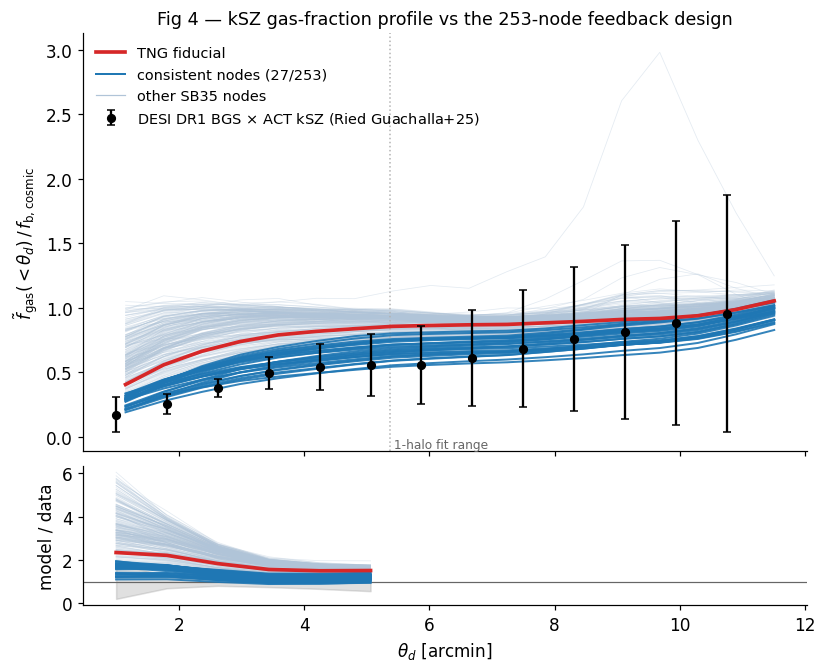

consistent: 27/253 (was 31 pre-fix; rank rho old-new = 0.97)


In [5]:
# ---- Fig 4: kSZ confrontation (bgs110, R6-corrected) -----------------------
tau = np.load(LC / "taucap_lightcone.npz", allow_pickle=True)
capm = np.load(LC / "capmat_lightcone.npz", allow_pickle=True)
k6 = np.load(LC / "ksz_consistent_nodes_r6.npz", allow_pickle=True)
d8 = np.load(ZEN / "Fig8_BGS_BRIGHT-20.2_logm11.00.npz")

N_XB = 18
F_B = float(capm["F_B"])
thr = V["R6"]["metrics"]["per_sample"]["bgs110"]["theta200_fid_arcmin"]
xbk = tau["theta_value"][:N_XB].astype(float)
with np.errstate(invalid="ignore", divide="ignore"):
    fgas_nodes = tau["sb35_mean_bgs110"][:, :N_XB] / capm["sb35_mean_bgs110"][:, :N_XB] / F_B
    fgas_fid = tau["fid_mean_bgs110"][:N_XB] / capm["fid_mean_bgs110"][:N_XB] / F_B
cons_ids = set(int(i) for i in k6["node_ids_bgs110"])
node_ids_all = k6["node_ids_all"]

fig, (ax, axr) = plt.subplots(2, 1, figsize=(7.4, 6.0), sharex=True,
                               height_ratios=[3, 1])
for i, nid in enumerate(node_ids_all):
    is_c = int(nid) in cons_ids
    ax.plot(xbk * thr, fgas_nodes[i], color=C["cons"] if is_c else C["nodes"],
            lw=1.3 if is_c else 0.5, alpha=0.9 if is_c else 0.35,
            zorder=3 if is_c else 1)
ax.plot(xbk * thr, fgas_fid, color=C["fid"], lw=2.4, zorder=4, label="TNG fiducial")
ax.errorbar(d8["th"], d8["ratio"], d8["yerr"], fmt="o", ms=5, color=C["data"],
            lw=1.5, capsize=2.5, zorder=5,
            label=r"DESI DR1 BGS $\times$ ACT kSZ (Ried Guachalla+25)")
ax.axvline(XB_ONEHALO_MAX * thr, color="0.7", ls=":", lw=1)
ax.text(XB_ONEHALO_MAX * thr, ax.get_ylim()[0], " 1-halo fit range ", fontsize=8,
        color="0.4", ha="left", va="bottom")
ax.plot([], [], color=C["cons"], lw=1.3, label=f"consistent nodes ({len(cons_ids)}/253)")
ax.plot([], [], color=C["nodes"], lw=0.8, label="other SB35 nodes")
ax.set_ylabel(r"$\tilde f_{\rm gas}(<\theta_d)\,/\,f_{\rm b,cosmic}$")
ax.set_title("Fig 4 — kSZ gas-fraction profile vs the 253-node feedback design")
ax.legend(frameon=False, loc="upper left")

# bottom panel: model/data ratio, each node's curve interpolated onto the
# data's theta grid and restricted to the 1-halo fit range (R1)
mask4 = d8["th"] <= XB_ONEHALO_MAX * thr
frac_err4 = d8["yerr"] / d8["ratio"]
axr.fill_between(d8["th"][mask4], 1 - frac_err4[mask4], 1 + frac_err4[mask4],
                  color="0.6", alpha=0.3, zorder=0)
axr.axhline(1.0, color="0.4", lw=0.8, zorder=1)
for i, nid in enumerate(node_ids_all):
    is_c = int(nid) in cons_ids
    interp_i = np.interp(d8["th"], xbk * thr, fgas_nodes[i])
    ratio_i = interp_i / d8["ratio"]
    axr.plot(d8["th"][mask4], ratio_i[mask4], color=C["cons"] if is_c else C["nodes"],
              lw=1.3 if is_c else 0.5, alpha=0.9 if is_c else 0.35,
              zorder=3 if is_c else 1)
interp_fid = np.interp(d8["th"], xbk * thr, fgas_fid)
ratio_fid = interp_fid / d8["ratio"]
axr.plot(d8["th"][mask4], ratio_fid[mask4], color=C["fid"], lw=2.4, zorder=4)
axr.set_ylabel("model / data")
axr.set_xlabel(r"$\theta_d$ [arcmin]")

fig.savefig(FIGDIR / "fig4_ksz_selection.png")
plt.show()
r6b = V["R6"]["metrics"]["per_sample"]["bgs110"]
print(f"consistent: {r6b['n_new_consistent']}/253 (was {r6b['n_old_consistent']} pre-fix; "
      f"rank rho old-new = {np.atleast_1d(r6b['spearman_old_vs_new_chi2'])[0]:.2f})")

### 3.2  The tSZ data reject the entire design: a strong-feedback tension

**Fig. 5** is the central result. Against our $y$-CAP measurement with the
complete correlated budget (§2.5), **no node of the design is consistent**:
the best node reaches $\chi^2=15.9$ for 6 degrees of freedom and the TNG
fiducial is rejected at $\chi^2/{\rm dof}=4.2$ ($p\approx3\times10^{-4}$),
over-predicting the smallest fit apertures by $5.0\times$ (declining to
$2.3\times$ at $x_b\simeq1.25$). The failure mode is *shape-coherent*: the
data fall faster toward small apertures than even the strongest-feedback
node, and the freedoms in the budget (mass anchor, satellites, CIB,
$A_{2h}$) are amplitude-like and cannot reproduce it. This is the map-level,
population-stacked analogue of the eROSITA group gas-fraction deficit
(Popesso et al. 2024) — reached with a completely independent instrument,
estimator, and systematics budget.

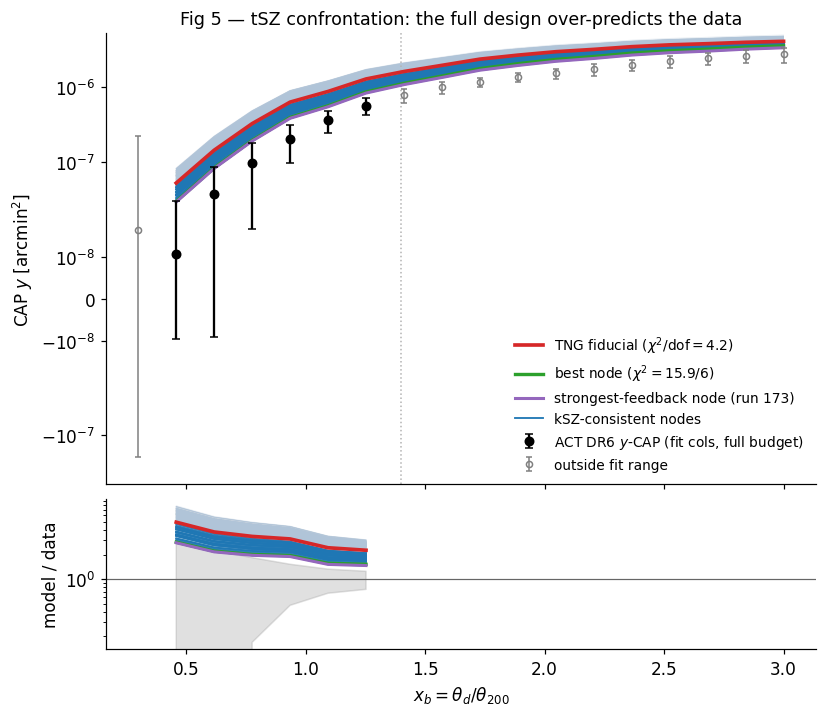

consistent with tSZ under full budget: 0/253
fiducial/data ratio over fit cols: [4.96 3.77 3.33 3.1  2.42 2.26]
strongest-feedback node (min f_in): run 173, f_in=0.464


In [6]:
# ---- Fig 5: tSZ money plot -------------------------------------------------
t3m = V["T3"]["metrics"]
node_mean_y = node_mean            # from Fig 3 cell: R2 kcal f0.08, R7-corrected
fid_y = np.nanmean(hd["fid_kcal_f0.08"], axis=0) * BIND_PIX_AREA / fcorr
sig_disp = np.sqrt((h_data * e17**2) + np.diag(r5c_["cov_cib"]))  # display error

lat5 = np.load(LC / "latent_constraints.npz", allow_pickle=True)
chi2_tsz_nodes = lat5["chi2_tsz"]
best = int(np.nanargmin(chi2_tsz_nodes))

# R2: strongest-feedback node = lowest f_in (Phase-L latent), matched into
# the Fig-5/Fig-4 node ordering (node_ids_all) by id, not by position
f_in = lat5["f_in"]
strongest = int(np.nanargmin(f_in))
run_id_strongest = int(lat5["node_ids"][strongest])
if np.array_equal(node_ids_all, lat5["node_ids"]):
    strongest_idx = strongest
else:
    print("WARNING: node_ids_all != latent_constraints node_ids; matching by id")
    match = np.nonzero(node_ids_all == run_id_strongest)[0]
    strongest_idx = int(match[0]) if len(match) else None

fig, (ax, axr) = plt.subplots(2, 1, figsize=(7.4, 6.4), sharex=True,
                               height_ratios=[3, 1])
for i in range(node_mean_y.shape[0]):
    is_c = int(node_ids_all[i]) in cons_ids
    ax.plot(xb, node_mean_y[i], color=C["cons"] if is_c else C["nodes"],
            lw=1.2 if is_c else 0.5, alpha=0.9 if is_c else 0.3,
            zorder=3 if is_c else 1)
ax.plot(xb, fid_y, color=C["fid"], lw=2.4, zorder=4,
        label=r"TNG fiducial ($\chi^2/{\rm dof}=%.1f$)" % t3m["chi2_fid_over_dof"])
ax.plot(xb, node_mean_y[best], color=C["best"], lw=2.2, zorder=4,
        label=r"best node ($\chi^2=%.1f/%d$)" % (t3m["chi2_nodes_min_med"][0], t3m["dof"]))
if strongest_idx is not None:
    ax.plot(xb, node_mean_y[strongest_idx], color="#9467bd", lw=2.0, zorder=4,
            label=f"strongest-feedback node (run {run_id_strongest})")
ax.errorbar(xb[iv], m17[iv], sig_disp[iv], fmt="o", ms=5.5, color=C["data"], lw=1.5,
            capsize=2.5, zorder=5, label="ACT DR6 $y$-CAP (fit cols, full budget)")
ax.errorbar(xb[~valid], m17[~valid], sig_disp[~valid], fmt="o", ms=4, mfc="none",
            color="0.5", lw=1, capsize=2, zorder=5, label="outside fit range")
ax.plot([], [], color=C["cons"], lw=1.2, label="kSZ-consistent nodes")
ax.axvline(XB_ONEHALO_MAX, color="0.7", ls=":", lw=1)
ax.set_yscale("symlog", linthresh=2e-8)
ax.set_ylabel(r"CAP $y$ [arcmin$^2$]")
ax.set_title("Fig 5 — tSZ confrontation: the full design over-predicts the data")
ax.legend(frameon=False, loc="lower right", fontsize=9)

# bottom panel: model/data ratio, restricted to the fit columns (iv) --
# data is near zero outside iv, so the ratio is not meaningful there
band_lo = 1 - sig_disp[iv] / np.abs(m17[iv])
band_hi = 1 + sig_disp[iv] / np.abs(m17[iv])
axr.fill_between(xb[iv], band_lo, band_hi, color="0.6", alpha=0.3, zorder=0)
axr.axhline(1.0, color="0.4", lw=0.8, zorder=1)
for i in range(node_mean_y.shape[0]):
    is_c = int(node_ids_all[i]) in cons_ids
    axr.plot(xb[iv], node_mean_y[i][iv] / m17[iv], color=C["cons"] if is_c else C["nodes"],
              lw=1.2 if is_c else 0.5, alpha=0.9 if is_c else 0.3,
              zorder=3 if is_c else 1)
axr.plot(xb[iv], fid_y[iv] / m17[iv], color=C["fid"], lw=2.4, zorder=4)
axr.plot(xb[iv], node_mean_y[best][iv] / m17[iv], color=C["best"], lw=2.2, zorder=4)
if strongest_idx is not None:
    axr.plot(xb[iv], node_mean_y[strongest_idx][iv] / m17[iv], color="#9467bd", lw=2.0,
              zorder=4)
axr.set_yscale("log")
axr.set_ylabel("model / data")
axr.set_xlabel(r"$x_b=\theta_d/\theta_{200}$")

fig.savefig(FIGDIR / "fig5_tsz_tension.png")
plt.show()
print(f"consistent with tSZ under full budget: {t3m['counts']['n_tsz_consistent']}/253")
print("fiducial/data ratio over fit cols:",
      np.round(t3m["fid_over_data_ratio_valid"], 2))
print(f"strongest-feedback node (min f_in): run {run_id_strongest}, "
      f"f_in={f_in[strongest]:.3f}")

### 3.3  The two probes agree on the ranking

A rejected model bank can still be *informative* if the probes order it the
same way. **Fig. 6**: the per-node kSZ and tSZ $\chi^2$ are strongly rank-
correlated (Spearman $\rho=0.82$, $p\sim10^{-63}$) — gas-poor nodes do better
on **both** probes, across a design in which 30 parameters vary
simultaneously. This coherence (not any consistency count) is the robust
qualitative claim: two SZ observables with disjoint systematics budgets
independently order the feedback space by the same physical property — how
much gas the feedback has removed from the group cores.

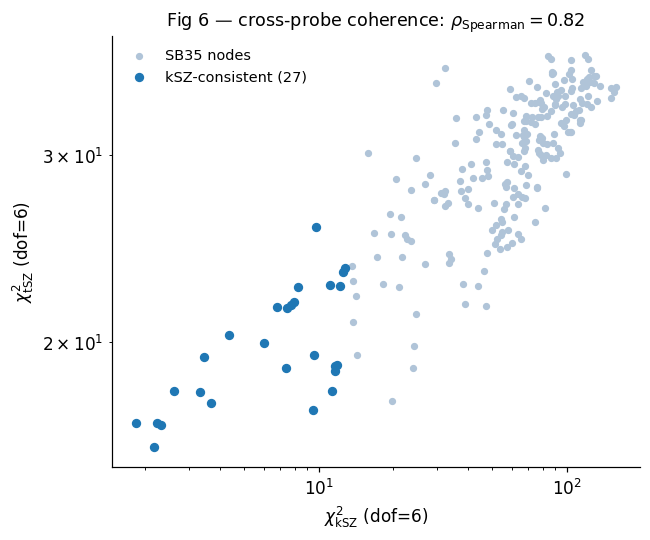

Spearman rho = 0.823 (p = 1.2e-63); T3 verdict value: 0.823


In [7]:
# ---- Fig 6: ranking coherence ---------------------------------------------
lat = np.load(LC / "latent_constraints.npz", allow_pickle=True)
c_k, c_t = lat["chi2_ksz"], lat["chi2_tsz"]
from scipy.stats import spearmanr
ok_ = np.isfinite(c_k) & np.isfinite(c_t)
rho, pv = spearmanr(c_k[ok_], c_t[ok_])

fig, ax = plt.subplots(figsize=(5.8, 4.8))
is_cons = np.array([int(n) in cons_ids for n in lat["node_ids"]])
ax.scatter(c_k[~is_cons], c_t[~is_cons], s=14, color=C["nodes"], label="SB35 nodes")
ax.scatter(c_k[is_cons], c_t[is_cons], s=26, color=C["cons"], zorder=3,
           label="kSZ-consistent (27)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\chi^2_{\rm kSZ}$ (dof=%d)" %
              V["R6"]["metrics"]["per_sample"]["bgs110"]["n_dof"])
ax.set_ylabel(r"$\chi^2_{\rm tSZ}$ (dof=%d)" % t3m["dof"])
ax.set_title(r"Fig 6 — cross-probe coherence: $\rho_{\rm Spearman}=%.2f$" % rho)
ax.legend(frameon=False)
fig.savefig(FIGDIR / "fig6_coherence.png")
plt.show()
print(f"Spearman rho = {rho:.3f} (p = {pv:.1e}); "
      f"T3 verdict value: {t3m['counts']['spearman_ksz110_vs_tsz_chi2'][0]:.3f}")

In [8]:
# N3: goodness-of-fit table
from scipy.stats import chi2

# kSZ data from R6 verdict
r6_bgs110 = V["R6"]["metrics"]["per_sample"]["bgs110"]
n_dof_ksz = r6_bgs110["n_dof"]
n_consistent_ksz = r6_bgs110["n_new_consistent"]

# tSZ data from T3 verdict
t3_metrics = V["T3"]["metrics"]
n_dof_tsz = t3_metrics["dof"]
chi2_fid_tsz = t3_metrics["chi2_fid_over_dof"] * n_dof_tsz
chi2_best_tsz = t3_metrics["chi2_nodes_min_med"][0]
pte_fid_tsz = chi2.sf(chi2_fid_tsz, n_dof_tsz)
pte_best_tsz = chi2.sf(chi2_best_tsz, n_dof_tsz)

n_tsz_consistent = t3_metrics["counts"]["n_tsz_consistent"]
spearman_rho = t3_metrics["counts"]["spearman_ksz110_vs_tsz_chi2"][0]

# Node chi2 distribution for the kSZ leg (latent_constraints holds the final
# per-node chain values; the TNG fiducial is a separate run, NOT among the
# 253 nodes -- its kSZ verdict is qualitative: gas-rich of the data, Fig 4)
lat = np.load(LC / "latent_constraints.npz", allow_pickle=True)
chi2_ksz = lat["chi2_ksz"]
chi2_best_ksz = np.nanmin(chi2_ksz)
chi2_med_ksz = np.nanmedian(chi2_ksz)
pte_best_ksz = chi2.sf(chi2_best_ksz, n_dof_ksz)

print()
print("=== Goodness-of-fit summary ===")
print(f"kSZ bgs110 (n_dof={n_dof_ksz}):")
print(f"  best node: χ²={chi2_best_ksz:.1f}  PTE={pte_best_ksz:.3f}")
print(f"  median node: χ²={chi2_med_ksz:.1f}")
print(f"  consistent: {n_consistent_ksz} / 253")
print(f"tSZ (n_dof={n_dof_tsz}):")
print(f"  fiducial: χ²={chi2_fid_tsz:.1f}  PTE={pte_fid_tsz:.2e}")
print(f"  best node: χ²={chi2_best_tsz:.1f}  PTE={pte_best_tsz:.2e}")
print(f"  consistent: {n_tsz_consistent} / 253")
print(f"joint ranking coherence: Spearman ρ = {spearman_rho:.2f}")


=== Goodness-of-fit summary ===
kSZ bgs110 (n_dof=6):
  best node: χ²=1.8  PTE=0.935
  median node: χ²=61.1
  consistent: 27 / 253
tSZ (n_dof=6):
  fiducial: χ²=25.0  PTE=3.47e-04
  best node: χ²=15.9  PTE=1.43e-02
  consistent: 0 / 253
joint ranking coherence: Spearman ρ = 0.82


Goodness-of-fit summary per probe (per-bin structure is visible in Figs 4-5):

| probe | verdict |
|---|---|
| **kSZ (bgs110)** | 27/253 nodes consistent; best node $\chi^2=1.8/6$ (PTE=0.93), median node $\chi^2=61$; the fiducial sits in the rejected gas-rich tail (Fig 4) |
| **tSZ** | 0/253 consistent; fiducial $\chi^2/{\rm dof}=4.2$ (PTE$\approx3\times10^{-4}$); best node $15.9/6$ (PTE=0.014) |
| **joint ranking** | Spearman $\rho=0.82$; both probes order the design by the same gas property |

### 3.4  Posterior inference: the gas plane and the parameter forest

Consistency counts depend on the error treatment (§5), so quantitative
statements come from a likelihood analysis (phase R8,
`examples/_r8_gp_mcmc.py`): per-column GP emulators over the design
(3-fold-validated, coverage-calibrated) feed a 33-dimensional `emcee` MCMC —
30 astro parameters + satellite fraction $f_{\rm sat}$ + mass-anchor offset
$\Delta\log M$ + two-halo amplitude $A_{2h}$ (Foreman-Mackey et al. 2013) —
with all chains run 740–1200 autocorrelation times (gate: 50).

**Fig. 7** projects the kSZ, tSZ, and joint posteriors into the physically
interpretable **gas plane** of the parent analysis — the 2-D latent that
captures 97% of the design's observable response, rotated so its axes track
$\tilde f_{\rm gas}(<R_{500})$ and the $R_{500}\!\to\!R_{200}$ shell gas
(both $r\simeq0.95$; the low dimensionality of feedback response echoes
Lin et al. 2026). The two probes **independently** land on the same
low-inner-gas region, and jointly:

$$\tilde f_{\rm gas}(<R_{500}) = 0.45^{+0.06}_{-0.06}, \qquad
  \tilde f_{\rm gas}(R_{500}\!\to\!R_{200}) = 0.95^{+0.05}_{-0.05}$$

of the cosmic baryon fraction — inner-halo gas at half cosmic, outskirts
near-cosmic, i.e. feedback that *redistributes* gas outward rather than
merely heating it in place. **Fig. 8** shows the 30-parameter forest: the
constrained directions are the wind-energy sector
(`WindEnergyIn1e51erg`, `VariableWindVelFactor` pulled low; `IMFslope`
pulled flat; `WindFreeTravelDensFac` high), but under an ESS-matched
Dirichlet look-elsewhere null **only `WindFreeTravelDensFac`** remains
individually significant — an honest statement of how much a 253-node
design can localize 30 parameters.

The nuisance posteriors stay physically plausible (mirroring the $A_{2h}$
check): the effective in-catalog satellite fraction comes out
$f_{\rm eff}=0.036^{+0.020}_{-0.019}$ — mildly below its $\kappa$-calibrated
prior $0.08\pm0.04$ and corresponding to a true LRG satellite fraction
$\simeq0.05$ versus the $\sim0.11$ HOD literature value (Yuan et al. 2023),
a $\sim1\sigma$ preference for less satellite boost, not an implausible
excursion — and the mass-anchor offset
$\Delta\log M = -0.012^{+0.081}_{-0.081}$ dex sits comfortably within the
Sailer et al. (2024) anchor uncertainty of $\pm0.1$ dex. No reconciliation
freedom is being exercised at an implausible value.

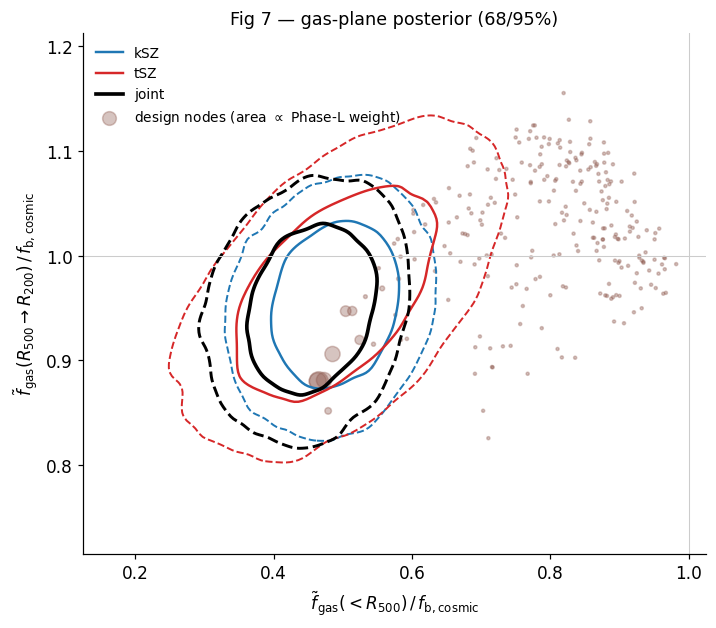

joint f_in 16/50/84: [0.392 0.453 0.512]  f_out: [0.896 0.95  1.001]


In [9]:
# ---- Fig 7: gas-plane posterior corner ------------------------------------
from scipy.stats import gaussian_kde
p8 = np.load(LC / "r8_posterior.npz", allow_pickle=True)
rng = np.random.default_rng(11)

def kde2(fx, fy, nmax=30000, grid=130):
    n = len(fx)
    if n > nmax:
        s = rng.choice(n, nmax, replace=False)
        fx, fy = fx[s], fy[s]
    kde = gaussian_kde(np.vstack([fx, fy]))
    gx = np.linspace(fx.min(), fx.max(), grid)
    gy = np.linspace(fy.min(), fy.max(), grid)
    GX, GY = np.meshgrid(gx, gy)
    Z = kde(np.vstack([GX.ravel(), GY.ravel()])).reshape(GX.shape)
    zs = np.sort(Z.ravel())[::-1]
    cz = np.cumsum(zs); cz /= cz[-1]
    levels = [zs[min(np.searchsorted(cz, q), len(zs) - 1)] for q in (0.95, 0.68)]
    return GX, GY, Z, levels

fig, ax = plt.subplots(figsize=(6.4, 5.6))
for leg, color, lw in [("ksz", C["cons"], 1.6), ("tsz", C["fid"], 1.6),
                       ("joint", "k", 2.4)]:
    GX, GY, Z, lv = kde2(p8[f"gas_fin_{leg}"], p8[f"gas_fout_{leg}"])
    ax.contour(GX, GY, Z, levels=lv, colors=[color], linewidths=[0.8 * lw, lw],
               linestyles=["--", "-"])
    ax.plot([], [], color=color, lw=lw, label={"ksz": "kSZ", "tsz": "tSZ",
                                               "joint": "joint"}[leg])
w = lat["w_joint"]; wf = w / w.sum()
ax.scatter(lat["f_in"], lat["f_out"], s=4 + 600 * wf, color="#8c564b", alpha=0.35,
           label="design nodes (area $\\propto$ Phase-L weight)")
ax.axvline(1.0, color="0.8", lw=0.7); ax.axhline(1.0, color="0.8", lw=0.7)
ax.set_xlabel(r"$\tilde f_{\rm gas}(<R_{500})\,/\,f_{\rm b,cosmic}$")
ax.set_ylabel(r"$\tilde f_{\rm gas}(R_{500}\to R_{200})\,/\,f_{\rm b,cosmic}$")
ax.set_title("Fig 7 — gas-plane posterior (68/95%)")
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.savefig(FIGDIR / "fig7_gas_plane.png")
plt.show()
gp = V["R8"]["metrics"]["gas_plane"]["joint"]
print("joint f_in 16/50/84:", np.round(gp["f_in_165084"], 3),
      " f_out:", np.round(gp["f_out_165084"], 3))

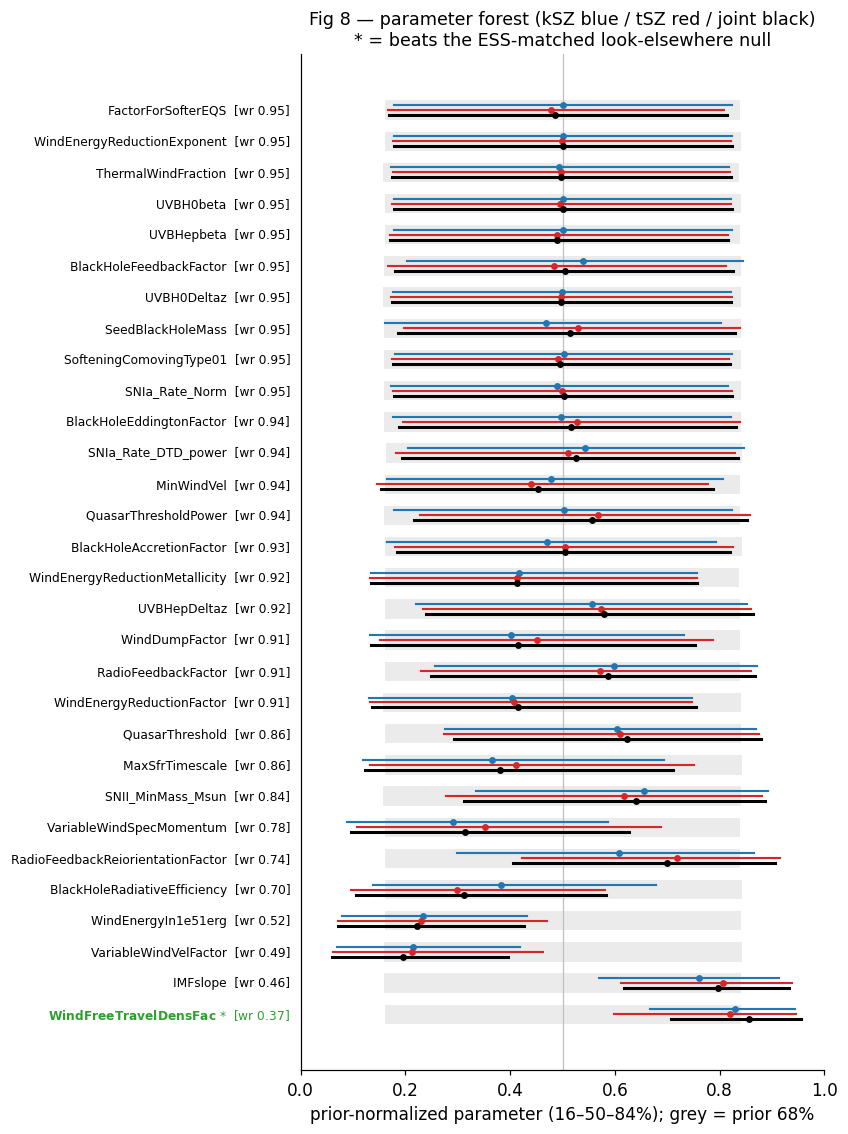

beats null: ['WindFreeTravelDensFac']  (of 30)
A_2h posterior (joint): [0.701 0.962 1.224]

Nuisance posteriors (joint):
  f_sat = 0.036 [0.017, 0.056] (16-50-84th %ile)
  dlogM = -0.012 [-0.093, 0.069] dex (16-50-84th %ile)


In [10]:
# ---- Fig 8: 30-parameter forest -------------------------------------------
names = [str(n) for n in p8["names"]][:30]
prior_q = p8["prior_q"]
le = V["R8"]["metrics"]["look_elsewhere_null"]["per_param"]
beats = set(V["R8"]["metrics"]["look_elsewhere_null"]["beating_params"])

qs = {leg: np.percentile(p8[f"chain_{leg}"][:, :30], [16, 50, 84], axis=0)
      for leg in ("ksz", "tsz", "joint")}
wr = (qs["joint"][2] - qs["joint"][0]) / (prior_q[:, 2] - prior_q[:, 0])
order = np.argsort(wr)[::-1]

fig, ax = plt.subplots(figsize=(7.6, 10.2))
for row, j in enumerate(order):
    y = len(order) - 1 - row
    ax.barh(y, prior_q[j, 2] - prior_q[j, 0], left=prior_q[j, 0], height=0.62,
            color="0.92", zorder=1)
    for leg, color, dy in [("ksz", C["cons"], 0.16), ("tsz", C["fid"], 0.0),
                           ("joint", "k", -0.16)]:
        q = qs[leg][:, j]
        ax.plot([q[0], q[2]], [y + dy] * 2, color=color, lw=2 if leg == "joint" else 1.4,
                zorder=3)
        ax.plot(q[1], y + dy, "o", ms=3.5, color=color, zorder=4)
    star = names[j] in beats
    lbl = ("$\\bf{%s}$" % names[j].replace("_", r"\_") + " *") if star else names[j]
    ax.text(-0.02, y, lbl + f"  [wr {wr[j]:.2f}]", ha="right", va="center",
            fontsize=8, color=C["best"] if star else "k",
            transform=ax.get_yaxis_transform())
ax.axvline(0.5, color="0.75", lw=0.8)
ax.set_yticks([])
ax.set_xlim(0, 1)
ax.set_xlabel("prior-normalized parameter (16–50–84%); grey = prior 68%")
ax.set_title("Fig 8 — parameter forest (kSZ blue / tSZ red / joint black)\n"
             "* = beats the ESS-matched look-elsewhere null")
fig.savefig(FIGDIR / "fig8_forest.png")
plt.show()
print("beats null:", sorted(beats), " (of 30)")
print("A_2h posterior (joint):",
      np.round(V["R8"]["metrics"]["r4_two_halo_a2h_nuisance"]
               .get("a2h_posterior_165084", {}).get("joint", []), 3)
      if isinstance(V["R8"]["metrics"].get("r4_two_halo_a2h_nuisance"), dict) else "see R8.json")

# N4: nuisance plausibility
fsat = np.percentile(p8["chain_joint"][:, 30], [16, 50, 84])
dlogm = np.percentile(p8["chain_joint"][:, 31], [16, 50, 84])
print()
print("Nuisance posteriors (joint):")
print(f"  f_sat = {fsat[1]:.3f} [{fsat[0]:.3f}, {fsat[2]:.3f}] (16-50-84th %ile)")
print(f"  dlogM = {dlogm[1]:.3f} [{dlogm[0]:.3f}, {dlogm[2]:.3f}] dex (16-50-84th %ile)")

## 4  Discussion

**The tension is physical, not instrumental.** The measurement pipeline
reproduces ACT DR5 clusters and the Liu et al. (2025) profiles (§2.3); the
random and rotated nulls are clean in the fit range; and the painting
fidelity of the emulator is *measured* against a hydrodynamic truth lightcone
at the exact stacking halos and apertures — BIND over-paints CAP-$y$ by
$+16.4\%\pm2\%$, which is divided out and explains only $\sim$1/6 of the
$2.3$–$5\times$ deficit. The unpainted two-halo term goes the *wrong way*:
adding the analytic floor ($A_{2h}\simeq1$, confirmed by its posterior)
*raises* the model further above the data. The freedoms that could mimic the
deficit — mass anchor, satellite fraction, CIB — are marginalized with
correlated templates and cannot reproduce its aperture dependence.

**Convergence with independent probes.** Three independent lines now point
at gas-poorer groups than fiducial simulations: X-ray gas fractions (eROSITA;
Popesso et al. 2024), kSZ profiles (Hadzhiyska et al. 2024; Ried Guachalla et
al. 2025; McCarthy et al. 2025), and weak-lensing + kSZ joint analyses
(Bigwood et al. 2024). Our contribution is the *model-space* statement: even
allowing all 30 IllustrisTNG feedback parameters to vary jointly across their
CAMELS-SB35 ranges, the thermal SZ data at DESI LRGs remain below the entire
family — the deficit is not a fiducial-tuning accident but a structural
property of the TNG feedback model at group scales. Within the design, the
data pull toward high `WindFreeTravelDensFac`, low wind energies, and flat
IMF slope — i.e. configurations that move gas out of $R_{500}$ efficiently
without over-heating what remains (Fig. 7's near-cosmic outskirt shell).

**Per-probe ledger for the preferred (strong-feedback, gas-poor) region:**

| probe | verdict |
|---|---|
| kSZ (DESI DR1 BGS × ACT, Ried Guachalla+25, R6-corrected) | 27/253 nodes consistent; selects the gas-poor edge |
| tSZ (our ACT DR6 y-CAP at DESI LRGs) | 0/253 consistent under the full budget; fiducial p≈3×10⁻⁴; data below the entire design |
| DES Y3 cosmic shear | no discrimination after amplitude marginalization (all 253 accepted); χ² co-ranking ρ≈0.70 retained as corroboration only |
| X-ray (eROSITA groups, lit.) | same direction: measured gas fractions below all tested simulations |

**What the gas plane means for lensing.** Through the van Daalen et al.
(2020) relation, $\tilde f_{\rm gas}(<R_{500})\simeq0.45$ at
$10^{13.2}\,M_\odot$ implies matter-power suppression at the strong end of
current cosmic-shear priors — consistent with the direction advocated by
Amon & Efstathiou (2022) and Bigwood et al. (2024) for resolving small-scale
lensing tensions. The 2-D gas plane (inner deficit + outskirt shell) is the
natural interface to pass to lensing analyses, echoing the low-dimensional
latent structure of feedback response found in Lin et al. (2026).

### 4.1  Implication for weak-lensing suppression (Fig. 10)

The gas-plane result of §3.4 has a direct translation onto weak lensing: van
Daalen, McCarthy & Schaye (2020) showed that the baryon fraction retained
inside $R_{500}$ of $10^{13-14}\,M_\odot$ groups tightly predicts the
suppression of the small-scale matter (and hence convergence) power spectrum
relative to gravity-only. We propagate this directly at map level rather
than through a fitting function: each of the 253 painted nodes was already
ray-traced into a convergence field on the shared TNG300-DMO lightcone, so
$S(\ell,z_s\!=\!1)=C_\ell^\kappa({\rm node})/C_\ell^\kappa({\rm DMO})$
(**Fig. 10**) is a direct measurement of each node's suppression curve, not
an extrapolation. Weighting every node's $S(\ell)$ curve by its joint-probe
importance $w_{\rm joint}$ — the same design-level $\chi^2$-importance
weights used in Fig. 7, an honest proxy for the R8 joint posterior over the
253-node design rather than a resampling of the chain itself (effective
sample size ${\rm ESS}\simeq6$, printed below, matching the Phase-L caveat
of §5) — gives the shaded orange 16–84% band: the data-preferred region of
the design sits at or beyond the strong-suppression edge of the 253-node
cloud, below both the unweighted design median and the TNG300-hydro truth
lightcone (red) across the plotted range, including the DES/LSST-relevant
$\ell\sim300$–$3000$ band (shaded grey). Two caveats keep this a translation
rather than a calibrated forecast input: the weighting is a design-level
importance proxy, not a draw from the actual R8 posterior (ESS quoted
above), and the TNG300 (205 Mpc$/h$) box underlying every node is only
marginally converged for the *absolute* amplitude of baryonic suppression
(Schaller et al. 2024) — the same shared-box caveat noted for the node
ranking in §5, here applying to suppression amplitude rather than rank.

loaded cached S(ell) matrix from /mnt/home/mlee1/ceph/bind_science/ksz_confront/lightcone/Sell_zs1_253.npz


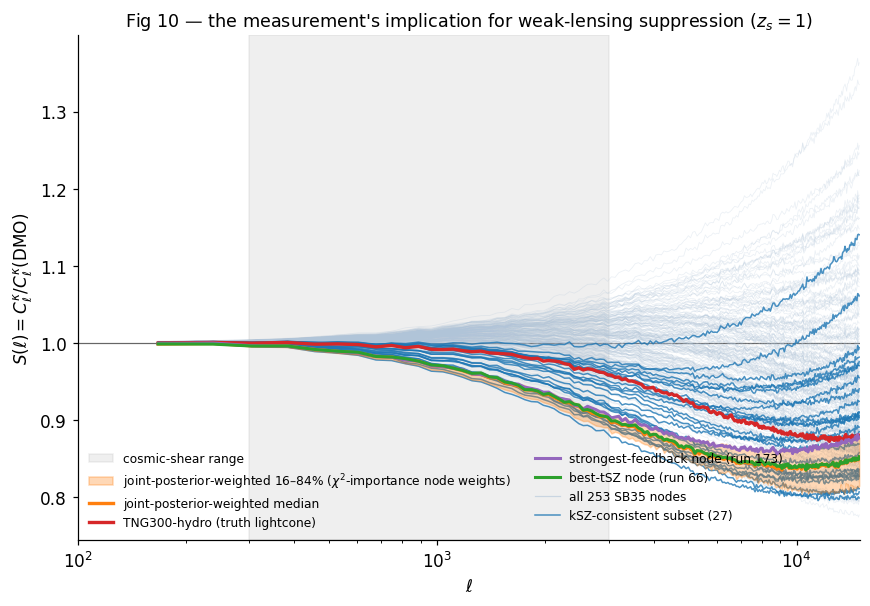

joint-posterior-weighted S(ell=2000): 16/50/84 = 0.922 / 0.934 / 0.937
joint-posterior-weighted S(ell=5000): 16/50/84 = 0.849 / 0.863 / 0.880
ESS(w_joint) = 6.0  (design-level chi2-importance weights; design-level proxy for the R8 joint posterior, cf. Phase-L ESS caveat in Sec.5)
unweighted design median S(2000) = 1.007, S(5000) = 0.979
named curves at ell=2000: TNG300-hydro truth = 0.977, strongest-feedback (run 173) = 0.936, best-tSZ (run 66) = 0.934


In [11]:
# ---- Fig 10: WL suppression-curve translation (S1) -------------------------
SB35_RUNS = Path("/mnt/home/mlee1/ceph/bind_sb35/runs")
DMO_CL = Path("/mnt/home/mlee1/ceph/bind_science/runs/dmo/run_0000/Cl_kappa.npz")
TRUTH_CL = Path("/mnt/home/mlee1/ceph/bind_science/runs/truth/run_0000/Cl_kappa.npz")
SELL_CACHE = LC / "Sell_zs1_253.npz"
ZS1_IDX = 1             # kappa_maps source_redshifts = [0.5, 1.0, 1.5, 2.0, 2.44]
ELL_TRUST_MAX = 1.5e4   # CIC aliasing dominates above this ell (Setup cell)

lat10 = np.load(LC / "latent_constraints.npz", allow_pickle=True)
node_ids10, w_joint10 = lat10["node_ids"], lat10["w_joint"]
f_in10, chi2_tsz10 = lat10["f_in"], lat10["chi2_tsz"]
k6_10 = np.load(LC / "ksz_consistent_nodes_r6.npz", allow_pickle=True)
cons_ids10 = set(int(i) for i in k6_10["node_ids_bgs110"])

cl_dmo10 = np.load(DMO_CL)
ell10 = cl_dmo10["ell"]
cl_dmo_zs1 = cl_dmo10["cl"][ZS1_IDX, ZS1_IDX]

if SELL_CACHE.exists():
    sc10 = np.load(SELL_CACHE)
    assert np.array_equal(sc10["ell"], ell10), "cached ell grid mismatch"
    assert np.array_equal(sc10["node_ids"], node_ids10), "cached node_ids mismatch"
    S10 = sc10["S"]
    print(f"loaded cached S(ell) matrix from {SELL_CACHE}")
else:
    S10 = np.empty((len(node_ids10), len(ell10)))
    for i10, nid10 in enumerate(node_ids10):
        d10 = np.load(SB35_RUNS / f"run_{int(nid10):04d}" / "Cl_kappa.npz")
        S10[i10] = d10["cl"][ZS1_IDX, ZS1_IDX] / cl_dmo_zs1
    np.savez(SELL_CACHE, ell=ell10, S=S10, node_ids=node_ids10)
    print(f"assembled 253-node S(ell) matrix -> cached to {SELL_CACHE}")

cl_truth10 = np.load(TRUTH_CL)
S_truth10 = cl_truth10["cl"][ZS1_IDX, ZS1_IDX] / cl_dmo_zs1

def _weighted_quantile(values, weights, qs):
    order = np.argsort(values)
    v, w = values[order], weights[order]
    cw = (np.cumsum(w) - 0.5 * w) / w.sum()
    return np.interp(qs, cw, v)

wn10 = w_joint10 / w_joint10.sum()
ess10 = 1.0 / np.sum(wn10 ** 2)
# joint-posterior-weighted 16/50/84 band of S(ell), per ell column
band10 = np.array([_weighted_quantile(S10[:, j], wn10, [0.16, 0.5, 0.84])
                    for j in range(S10.shape[1])]).T   # (3, nell)

trust10 = (ell10 >= 100) & (ell10 <= ELL_TRUST_MAX)
strongest10 = int(np.argmin(f_in10))
run_strongest10 = int(node_ids10[strongest10])
best_tsz10 = int(np.nanargmin(chi2_tsz10))
run_best_tsz10 = int(node_ids10[best_tsz10])
is_cons10 = np.array([int(n) in cons_ids10 for n in node_ids10])

fig, ax = plt.subplots(figsize=(7.8, 5.4))
for i10 in np.nonzero(~is_cons10)[0]:
    ax.plot(ell10[trust10], S10[i10, trust10], color=C["nodes"], lw=0.5, alpha=0.25,
            zorder=1)
for i10 in np.nonzero(is_cons10)[0]:
    ax.plot(ell10[trust10], S10[i10, trust10], color=C["cons"], lw=1.0, alpha=0.8,
            zorder=2)
ax.axvspan(300, 3000, color="0.6", alpha=0.15, zorder=0, label="cosmic-shear range")
ax.fill_between(ell10[trust10], band10[0, trust10], band10[2, trust10], color=C["band"],
                alpha=0.30, zorder=3,
                label=r"joint-posterior-weighted 16–84% ($\chi^2$-importance node weights)")
ax.plot(ell10[trust10], band10[1, trust10], color=C["band"], lw=2.2, zorder=4,
        label="joint-posterior-weighted median")
ax.plot(ell10[trust10], S_truth10[trust10], color=C["fid"], lw=2.2, zorder=5,
        label="TNG300-hydro (truth lightcone)")
ax.plot(ell10[trust10], S10[strongest10, trust10], color="#9467bd", lw=2.0, zorder=5,
        label=f"strongest-feedback node (run {run_strongest10})")
ax.plot(ell10[trust10], S10[best_tsz10, trust10], color=C["best"], lw=2.0, zorder=5,
        label=f"best-tSZ node (run {run_best_tsz10})")
ax.plot([], [], color=C["nodes"], lw=0.8, alpha=0.6, label="all 253 SB35 nodes")
ax.plot([], [], color=C["cons"], lw=1.0, alpha=0.8, label="kSZ-consistent subset (27)")
ax.axhline(1.0, color="0.4", lw=0.8, zorder=0)
ax.set_xscale("log")
ax.set_xlim(100, ELL_TRUST_MAX)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$S(\ell) = C_\ell^\kappa / C_\ell^\kappa({\rm DMO})$")
ax.set_title("Fig 10 — the measurement's implication for weak-lensing suppression ($z_s=1$)")
ax.legend(frameon=False, fontsize=8.0, ncol=2, loc="lower left")
fig.savefig(FIGDIR / "fig10_suppression.png")
plt.show()

s_at_2000_10 = np.array([np.interp(2000, ell10, S10[i]) for i in range(S10.shape[0])])
s_at_5000_10 = np.array([np.interp(5000, ell10, S10[i]) for i in range(S10.shape[0])])
q2000_10 = _weighted_quantile(s_at_2000_10, wn10, [0.16, 0.5, 0.84])
q5000_10 = _weighted_quantile(s_at_5000_10, wn10, [0.16, 0.5, 0.84])
s_truth_2000 = float(np.interp(2000, ell10, S_truth10))
s_strong_2000 = float(np.interp(2000, ell10, S10[strongest10]))
s_best_2000 = float(np.interp(2000, ell10, S10[best_tsz10]))
print(f"joint-posterior-weighted S(ell=2000): 16/50/84 = "
      f"{q2000_10[0]:.3f} / {q2000_10[1]:.3f} / {q2000_10[2]:.3f}")
print(f"joint-posterior-weighted S(ell=5000): 16/50/84 = "
      f"{q5000_10[0]:.3f} / {q5000_10[1]:.3f} / {q5000_10[2]:.3f}")
print(f"ESS(w_joint) = {ess10:.1f}  (design-level chi2-importance weights; "
      f"design-level proxy for the R8 joint posterior, cf. Phase-L ESS caveat in Sec.5)")
print(f"unweighted design median S(2000) = {np.median(s_at_2000_10):.3f}, "
      f"S(5000) = {np.median(s_at_5000_10):.3f}")
print(f"named curves at ell=2000: TNG300-hydro truth = {s_truth_2000:.3f}, "
      f"strongest-feedback (run {run_strongest10}) = {s_strong_2000:.3f}, "
      f"best-tSZ (run {run_best_tsz10}) = {s_best_2000:.3f}")

## 5  Caveats & robustness

**Consistency counts are treatment-dependent — the headline is not.**
Across defensible error treatments the number of "tSZ-consistent" nodes
swings between 0 and 119 (**Fig. 9**); with the complete correlated budget it
is 0. We therefore *never* lead with counts: the invariants are the deficit
direction/amplitude and the cross-probe ranking coherence
($\rho=0.82$–$0.90$ across all treatments). All 21 analysis decisions with
their pre/post-hoc status and triggers are in `docs/p4c_decisions_table.md`;
the headline moved *against* the initially-favorable framing (consistency
$\to$ tension) as the budget was completed, which is the opposite of
confirmation bias.

Other caveats, each quantified in its verdict:

- **Model family**: the design spans IllustrisTNG's 30 astro parameters at
  fixed cosmology (TNG300). The conclusion "no node fits" is a statement
  about this family; SIMBA/Astrid-family sweeps could differ (CAMELS shows
  their feedback modes are qualitatively distinct; Ni et al. 2023).
- **Painting floor**: only halos $\ge10^{13}\,h^{-1}M_\odot$ are painted;
  the missing diffuse/2-halo signal is handled by the R4 analytic template
  and the $x_b\le1.4$ fit range, not by the emulator itself.
- **Shared DMO base**: all nodes share one TNG300-Dark realization; sample
  variance is common-mode across nodes (helps ranking, limits absolute
  covariance realism). BIND realization scatter is propagated per node
  (Hartlap-corrected), but a single N-body box underlies everything. The
  measured per-node realization scatter in the CAP matrices is 19.4%
  (P6b.json `capmat_realization_scatter_pct`, bgs110) and enters each node's
  covariance; separately, box-size convergence of baryonic suppression
  itself requires large volumes (Schaller et al. 2024), which the 205 Mpc/h
  TNG300 box only marginally satisfies — a caveat on absolute amplitudes,
  not on the node ranking.
- **kSZ external covariance**: the release's own sample-covariance estimator
  count is unpublished, so its Hartlap factor cannot be applied (flagged in
  R6.json); the primary cut is the one stable under our unit fix.
- **GP emulation**: likelihoods are GP-emulated over 253 nodes with
  coverage-calibrated uncertainties (temperature 1.2–1.5$\times$); posterior
  tails beyond the design hull are prior-dominated by construction.
- **Look-elsewhere honesty**: the earlier importance-sampling analysis
  (Phase L, ESS$\sim$6) produced a "stable constrained pair" that did NOT
  survive the Dirichlet null — retained here as a methodological warning
  that robustness checks are not null tests.
- **Measured-but-secondary splits**: the EBV$<$0.15 dust-cut variant shifts the
  data vector by only 0.05–0.07$\sigma$ (decision #18); a broader
  $z=0.45$–0.9 window was measured (T2 products) and behaves consistently —
  both retained as variants, not cuts.

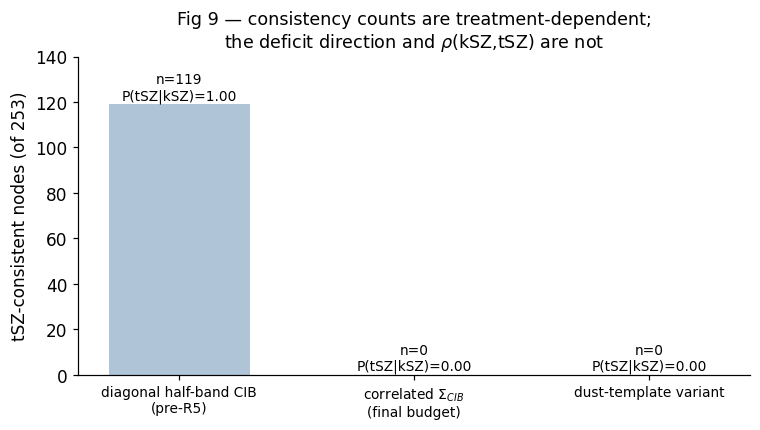

chi2_med by treatment: {'diag_halfband': 13.5, 'correlated': 40.1, 'dust_template': 55.1}
threshold scan (final budget): {'slack1': {'n': 0, 'P_tsz': 0.0, 'P_tsz_given_ksz110': 0.0}, 'slack2': {'n': 0, 'P_tsz': 0.0, 'P_tsz_given_ksz110': 0.0}, 'slack3': {'n': 1, 'P_tsz': 0.003952569169960474, 'P_tsz_given_ksz110': 0.037037037037037035}, 'p>0.05': {'n': 0, 'P_tsz': 0.0, 'P_tsz_given_ksz110': 0.0}, 'p>0.01': {'n': 4, 'P_tsz': 0.015810276679841896, 'P_tsz_given_ksz110': 0.14814814814814814}}


In [12]:
# ---- Fig 9: counts by treatment (the honesty figure) -----------------------
cbt = V["R5"]["metrics"]["counts_by_treatment"]
t3c = V["T3"]["metrics"]["counts"]
labels = ["diagonal half-band CIB\n(pre-R5)", "correlated $\\Sigma_{CIB}$\n(final budget)",
          "dust-template variant"]
keys = ["diag_halfband", "correlated", "dust_template"]
ns = [cbt[k]["n"] for k in keys]
rhos = [cbt[k].get("P_given_ksz", np.nan) for k in keys]

fig, ax = plt.subplots(figsize=(6.8, 3.8))
bars = ax.bar(range(len(keys)), ns, color=[C["nodes"], C["cons"], C["null"]], width=0.6)
for i, (n, r) in enumerate(zip(ns, rhos)):
    ax.text(i, n + 2, f"n={n}\nP(tSZ|kSZ)={r:.2f}", ha="center", fontsize=9)
ax.set_xticks(range(len(keys))); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("tSZ-consistent nodes (of 253)")
ax.set_ylim(0, 140)
ax.set_title("Fig 9 — consistency counts are treatment-dependent;\n"
             "the deficit direction and $\\rho$(kSZ,tSZ) are not")
fig.savefig(FIGDIR / "fig9_treatment.png")
plt.show()
print("chi2_med by treatment:",
      {k: round(cbt[k]["chi2_med"], 1) for k in keys})
print(f"threshold scan (final budget): {t3c['threshold_scan']}")

## 6  Conclusions

1. **We measured** a new ACT DR6 Compton-$y$ CAP profile at 160,150 DESI DR1
   SGC spectroscopic LRGs (S/N 4–15 per aperture), validated against ACT DR5
   clusters and Liu et al. (2025) — identifying, along the way, release bugs
   in two external data products (the Liu et al. csv $p_z$-bin duplication;
   the Ried Guachalla et al. `cov_ksz` unit mix-up), both reported with
   byte-level evidence.
2. **No node of the 253-point IllustrisTNG feedback design fits the tSZ
   data** under the complete correlated error budget (best $\chi^2=15.9/6$;
   fiducial $p\approx3\times10^{-4}$, $2.3$–$5\times$ over-prediction) —
   while the kSZ and tSZ rankings agree at $\rho=0.82$: both probes demand
   the strong-feedback, gas-poor edge and then some.
3. **The joint posterior localizes the gas latent**, not the parameters:
   $\tilde f_{\rm gas}(<R_{500})=0.45\pm0.06$,
   $\tilde f_{\rm gas}(R_{500}\!\to\!R_{200})=0.95\pm0.05$ of cosmic —
   inner-gas-poor, outskirt-near-cosmic groups. Only one of 30 parameters
   (`WindFreeTravelDensFac`) survives a look-elsewhere null.
4. **Methodologically**, map-level emulation makes many-model SZ
   confrontation tractable (253 full forward models), but the error budget —
   satellites, CIB correlations, painting fidelity, external covariance
   audits — is where the conclusion is actually decided; consistency counts
   without that budget are close to meaningless (0 vs 119 on the same data).
5. **Propagated to weak lensing** (Fig. 10, §4.1), the joint-posterior
   weighting of the design implies a $z_s=1$ convergence-spectrum
   suppression $S(\ell\!=\!2000) = 0.934^{+0.003}_{-0.012}$ (16–84%;
   $S(\ell\!=\!5000) = 0.863^{+0.017}_{-0.014}$) — below the unweighted
   design median ($1.01$) and the TNG300-hydro truth lightcone ($0.98$), at
   the strong-suppression end of current cosmic-shear baryon priors (van
   Daalen et al. 2020; Amon & Efstathiou 2022; Bigwood et al. 2024).

**Released with this paper:** the measured y-CAP data vector and covariance
(`RELEASE/act_ycap_lrg_real.npz`), the documented MCMC chains (`r8_posterior.npz`),
and a drop-in 2-D Gaussian gas-plane prior for baryonification analyses
(`RELEASE/gasplane_prior.npz`, with mean $(0.452, 0.949)$ and documented covariance;
Gaussian fidelity 1.00) — see the reproducibility appendix for data dictionaries and usage.

## 7  Future work

- **Velocity-aware kSZ.** BIND currently paints the electron column; pairing
  it with a DMO-derived velocity surrogate would build $\Delta T_{\rm kSZ}$
  directly and unlock pairwise/velocity-weighted estimators.
- **Cross-family designs.** Repeating the confrontation on SIMBA- and
  Astrid-family CAMELS sweeps tests whether *any* current feedback model
  family reaches the data, or whether the deficit indicts subgrid physics
  more broadly.
- **Cosmology dependence.** The design holds cosmology fixed; a joint
  cosmo+astro design would let the SZ gas plane be marginalized directly in
  cosmic-shear analyses (the natural continuation of Amon & Efstathiou 2022;
  Bigwood et al. 2024).
- **WL integration.** The $\kappa\times y$ cross-correlation was the most
  feedback-sensitive WL statistic in our earlier suite work; folding it in
  (with the DES demotion lessons of decision #20) would close the loop
  between the gas plane and the matter power spectrum.
- **Deeper SZ data.** Advanced ACTPol/SO depth improves the small-aperture
  columns where the tension is largest; the aperture-resolved deficit shape
  is a falsifiable prediction for Simons Observatory stacking.

## References

*(Author-year citations used in the narrative. arXiv identifiers included
where certain; verify all entries against ADS before submission.)*

- Amodeo S., et al., 2021, PRD 103, 063514 (ACT DR5 thermodynamic profiles)
- Amon A., Efstathiou G., 2022, MNRAS 516, 5355
- Battaglia N., Bond J.R., Pfrommer C., Sievers J.L., 2012, ApJ 758, 75
- Bigwood L., et al., 2024, MNRAS (WL + kSZ baryon feedback; arXiv:2404.06098)
- Chisari N.E., et al., 2019, Open J. Astrophys. 2, 4
- Coulton W., et al., 2024, PRD 109, 063530 (ACT DR6 component-separated maps)
- Foreman-Mackey D., Hogg D.W., Lang D., Goodman J., 2013, PASP 125, 306
- Hadzhiyska B., et al., 2024 (DESI photometric LRG kSZ; arXiv:2407.07152)
- Hartlap J., Simon P., Schneider P., 2007, A&A 464, 399
- Hilton M., et al., 2021, ApJS 253, 3 (ACT DR5 cluster catalog)
- Lin et al., 2026 (feedback response latent; arXiv:2509.01881)
- Liu et al., 2025 (ACT DR6 y-CAP at DESI photometric LRGs)
- McCarthy I.G., et al., 2025 (FLAMINGO vs stacked kSZ)
- Ni Y., et al., 2023, ApJ (CAMELS extended parameter sweeps)
- Popesso P., et al., 2024 (eROSITA group gas fractions)
- Ried Guachalla B., et al., 2025 (DESI DR1 spectroscopic kSZ profiles)
- Sailer N., et al., 2024 (DESI LRG lensing mass calibration)
- Schaller J., et al., 2024 (FLAMINGO convergence)
- Schaan E., et al., 2021, PRD 103, 063513 (ACT DR5 kSZ CAP)
- Sunyaev R.A., Zel'dovich Ya.B., 1972, Comm. Astrophys. Space Phys. 4, 173
- van Daalen M.P., McCarthy I.G., Schaye J., 2020, MNRAS 491, 2424
- Villaescusa-Navarro F., et al., 2021, ApJ 915, 71 (CAMELS)
- Yuan H., et al., 2023 (DESI LRG HOD)

## Reproducibility appendix

### Campaign resources

| item | location |
|------|----------|
| campaign plan / hardening plan | `docs/tsz_des_data_plan.md`, `docs/p4c_referee_hardening_plan.md` |
| decision registry (21 choices, pre/post-hoc) | `docs/p4c_decisions_table.md` |
| measurement engine | `examples/act_ycap_measure.py` |
| tSZ comparison chain | `examples/lightcone_m2r_ycap_real.py` |
| kSZ audit / covariance fix | `examples/_r6_ksz_audit.py` |
| satellite HOD stacks | `examples/lightcone_hod_stack.py` |
| fidelity closure / 2-halo | `examples/_r7_fidelity_closure.py`, `examples/_r4_twohalo.py` |
| GP+MCMC | `examples/_r8_gp_mcmc.py` (chains: `r8_state/`, posterior: `r8_posterior.npz`) |
| verdicts (all gates) | `KS/lightcone/verdicts/*.json` |
| git tag | `p4c-hardened-v1` on `analysis/ksz-desi-act-v2` |

### Figure-by-figure input products and engine chain

| fig | data/verdict inputs | engine(s) that produced them | released as |
|---|---|---|---|
| **1** — ACT DR6 y-CAP measurement | `act_ycap_lrg_real.npz` (data vector, covariance, nulls) | `act_ycap_measure.py` (T1/T2/T2f LRG+null+variant measurement shards) → `lightcone_m2r_ycap_real.py` (merge, resample correction, CIB covariance) | `RELEASE/act_ycap_lrg_real.npz` |
| **2** — pipeline validation | `T1_dr5_snr5.npz`, `R5_liu_pz{1..4}_cib1.7.npz`, `verdicts/T1.json`, `verdicts/R5.json` | `act_ycap_measure.py --mode dr5` (ACT DR5 clusters); `act_ycap_measure.py --mode liu` (Liu et al. 2025 photometric LRGs, pz bins 1–4); `_r5c_liu_figure.py` (reproduction metrics) | none |
| **3** — error-budget decomposition | `R1_resample_correction.npz`, `R2_hod_model_curves.npz`, `R3_mass_template.npz`, `R5_cib_cov.npz`, `verdicts/R7.json`, `verdicts/R4.json` | `_r1_closure.py` → `lightcone_hod_stack.py` (+ HOD disBatch sweep) → `_r3_mass_anchor.py` → `_r5_cib_systematics.py` → `_r7_fidelity_closure.py` → `_r4_twohalo.py` | none |
| **4** — kSZ selection | `taucap_lightcone.npz`, `capmat_lightcone.npz`, `ksz_consistent_nodes_r6.npz`, Ried Guachalla+2025 kSZ profile (Zenodo 19160138) | `lightcone_m1_fgas_desiact.py` (map-level f_gas vs. published kSZ) → `_r6_ksz_audit.py` (covariance-unit fix, consistency audit) | none |
| **5** — tSZ tension | `act_ycap_lrg_real.npz`, `R2_hod_model_curves.npz`, `latent_constraints.npz`, `verdicts/T3.json`, `verdicts/R7.json` | `lightcone_m2r_ycap_real.py` (tSZ x BIND comparison, verdicts/T3.json) → `lightcone_latent_corner.py` (gas-latent PCA, chi2 aggregation) | none |
| **6** — cross-probe ranking | `latent_constraints.npz` (keys: `chi2_ksz`, `chi2_tsz`) | `_r6_ksz_audit.py` (kSZ chi2 from covariance fix) → `lightcone_m2r_ycap_real.py` (tSZ chi2) → `lightcone_latent_corner.py` (merge into single npz) | none |
| **7** — gas-plane posterior | `r8_posterior.npz` (keys: `chain_joint`, `gas_fin_joint`, `gas_fout_joint`), `latent_constraints.npz` (key: `w_joint`), `verdicts/R8.json` | `_r8_gp_mcmc.py --stage all` (GP emulation over 253 nodes, emcee MCMC over 33-d parameter + nuisance space, 740–1200 autocorr-time chains) → `run_r8_finalize.sh` (chain post-processing, gas-plane projection) | `r8_posterior.npz` |
| **8** — 30-parameter forest | `r8_posterior.npz` (key: `chain_joint`), `verdicts/R8.json` (key: `look_elsewhere_null.per_param`) | `_r8_gp_mcmc.py --stage chain` (emcee chain over 30 astro + 3 nuisance) → `run_r8_finalize.sh` (look-elsewhere null assembly per parameter) | `r8_posterior.npz` |
| **9** — consistency counts (honesty) | `verdicts/R5.json` (key: `counts_by_treatment`), `verdicts/T3.json` (key: `metrics.counts`) | `_r5_cib_systematics.py` (CIB covariance, count comparison across budget treatments) + `lightcone_m2r_ycap_real.py` (final-budget threshold scan) | none |
| **10** — WL suppression ($S(\ell)$) | `latent_constraints.npz` (keys: `node_ids`, `w_joint`), `Sell_zs1_253.npz` (cached per-node `S(\ell,z_s=1)` suppression curves), `Cl_kappa.npz` from each bind_sb35 run node (via SB35_RUNS path), paired DMO trace (`runs/dmo/run_0000/Cl_kappa.npz`), truth lightcone (`runs/truth/run_0000/Cl_kappa.npz`) | assembled in-notebook by the Fig 10 cell from the stored per-run `Cl_kappa.npz` spectra (builds the `Sell_zs1_253.npz` cache on first run; recipe adapted from `lightcone_transfer.py` on branch `analysis/wl-cosmo-bias`) | none |

This notebook: built by `examples/_build_p4c_paper_nb.py`; paper figures are
written to `KS/lightcone/figs/paper/`.